In [3]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../')

from pathlib import Path

import phys_ml.visualization.vertex_visualization as vertvis
import phys_ml.visualization.base as vis
from phys_ml.analysis.vertex import *
from phys_ml.evaluation import vertex as verteval
from phys_ml.load_data.vertex import *
from phys_ml.trainer.vertex import *
from phys_ml.util import slurm_generate

data_dir = Path('/gpfs/data/fs71925/shepp123/frgs_6d/')
rmse_df = pd.read_csv('reconstruction_results.csv')
classification_df = pd.read_pickle('classification_results.pkl')

## contents

&emsp;0&emsp;on real space  
&emsp;1&emsp;trained on all vertices  
&emsp;&emsp;1-1&emsp;simple autoencoder  
&emsp;&emsp;1-2&emsp;contrastive autoencoder  
&emsp;2&emsp;trained on only 2 phases  
&emsp;&emsp;2-1&emsp;exclude SC-phase  
&emsp;&emsp;&emsp;2-1-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-1-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-2&emsp;exclude AFM-phase  
&emsp;&emsp;&emsp;2-2-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-2-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-3&emsp;exclude FM-phase  
&emsp;&emsp;&emsp;2-3-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-3-2&emsp;contrastive autoencoder  
&emsp;3&emsp;trained on only 1 phase  
&emsp;&emsp;3-1&emsp;SC-phase  
&emsp;&emsp;3-2&emsp;AFM-phase  
&emsp;&emsp;3-3&emsp;FM-phase  
&emsp;4&emsp;correlation  
&emsp;5&emsp;convergence  

## visualize vertex

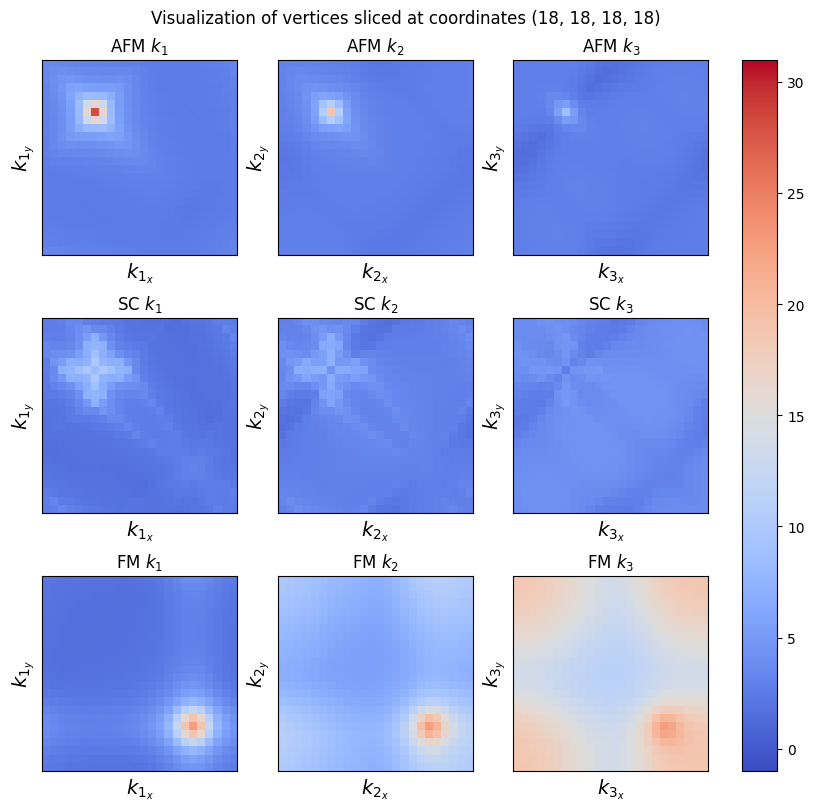

In [20]:
files_names = ['tp0.000000_mu0.000000', 'tp0.270000_mu1.080000', 'tp0.500000_mu2.000000']
vertices = [AutoEncoderVertex24x6Dataset.load_from_file(data_dir / f'{fn}.h5') for fn in files_names]
vertvis.plot_compare_slices(vertices)

## vertex statistics

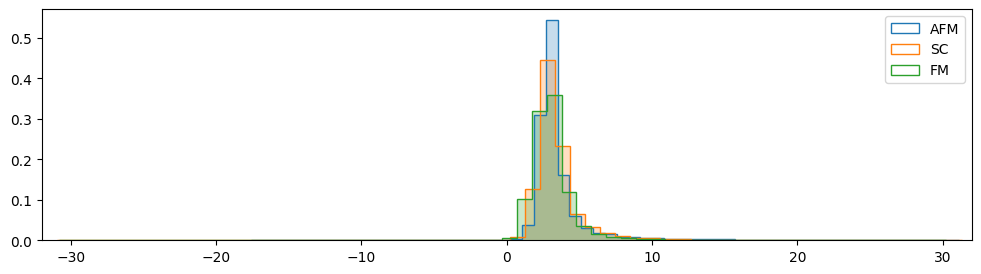

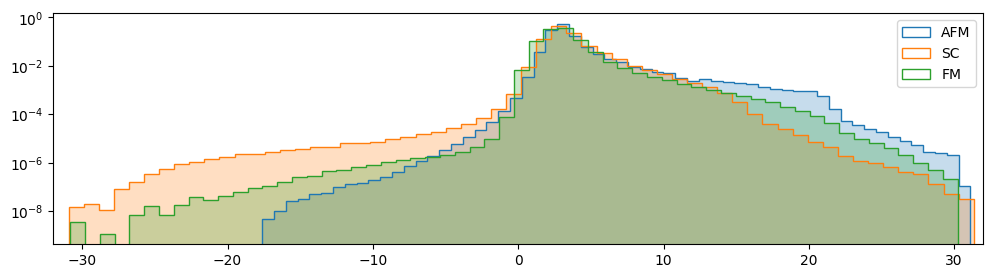

,min,max,mean,sum
AFM,-17.621026,31.116854,3.516467,13440147922.163141
SC,-30.943928,31.344199,3.435302,13129930305.072977
FM,-30.830774,30.236403,3.128338,11956693254.854389


In [3]:
df, data = verteval.vertex_statistics(data_dir)
verteval.plot_statistics(data)
verteval.plot_statistics(data, log=True)
df

## correlation

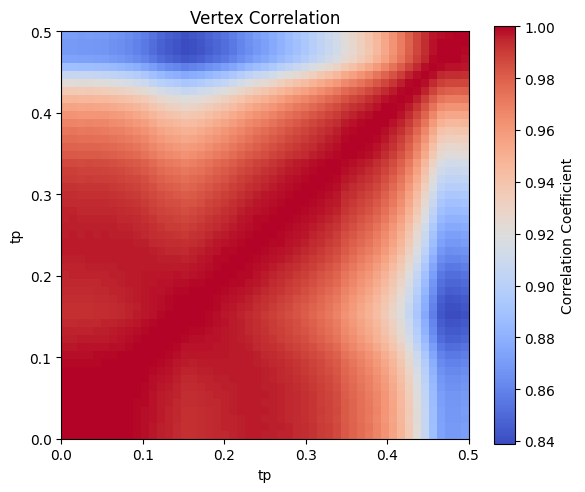

In [5]:
cor_mat = np.load(f'cor_mat_vertex24x6.npy')
vertvis.plot_correlation(cor_mat, "Vertex Correlation")

## compare autoencoder models

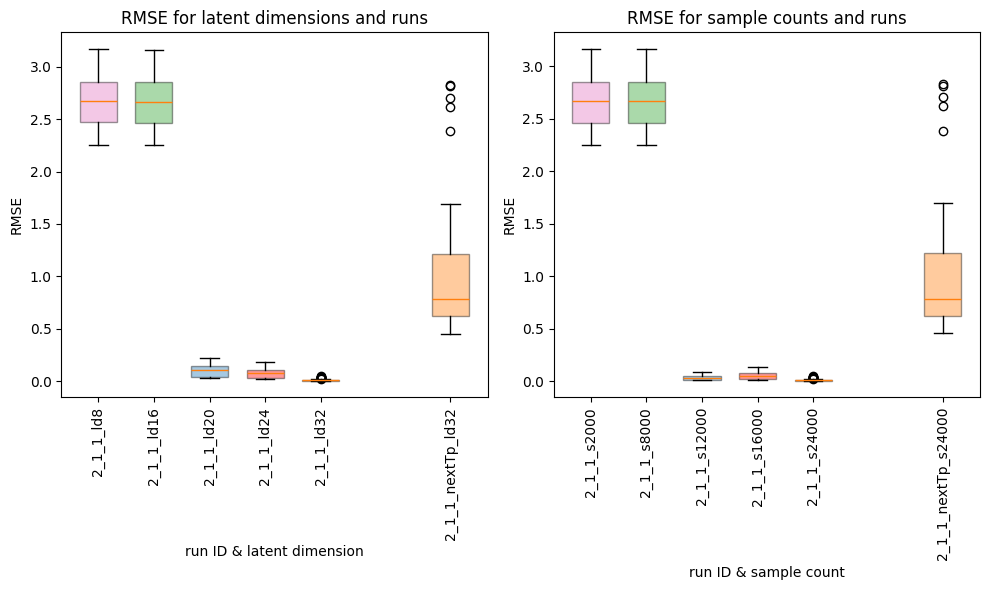

rmse
run_id       ld s              
2_1_1        8  24000  2.683142
             16 24000  2.675942
             20 24000  0.104619
             24 24000  0.080148
             32 2000   2.676035
                8000   2.674256
                12000  0.035785
                16000  0.055903
                24000  0.013185
2_1_1_nextTp 32 24000  1.019841

In [12]:
verteval.plot_all_rmses(rmse_df[rmse_df['run_id'].str.startswith('2_1_1')], figsize=(10, 6))

mean: 0.007131751916505284, min: 0.003990790062044, max: 0.0172411753513762
training data only - mean: 0.007131751916505284, min: 0.003990790062044, max: 0.0172411753513762


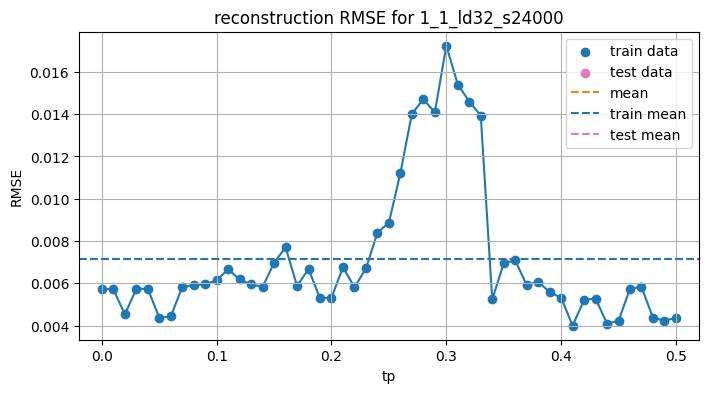

mean: 0.08068483307527777, min: 0.0236572626566888, max: 0.1771952141563764
training data only - mean: 0.08068483307527777, min: 0.0236572626566888, max: 0.1771952141563764


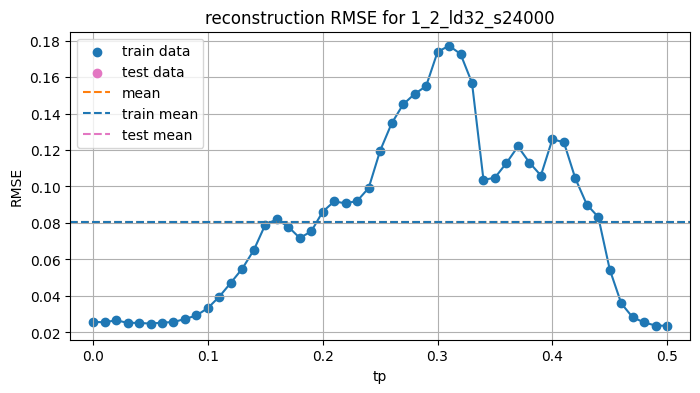

mean: 2.683142388932142, min: 2.2540576223933195, max: 3.1704341774024543
training data only - mean: 2.7464495410820935, min: 2.336437330842606, max: 3.1704341774024543
test data only - mean: 2.5927036001464976, min: 2.2540576223933195, max: 3.1509483410550336


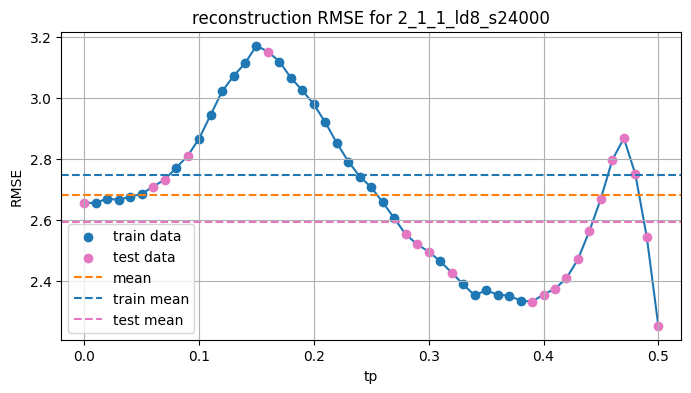

mean: 2.6759416311093522, min: 2.2519051169987305, max: 3.1623546175503128
training data only - mean: 2.7384500874985234, min: 2.326000505149761, max: 3.1623546175503128
test data only - mean: 2.5866438362676782, min: 2.2519051169987305, max: 3.1416485278473485


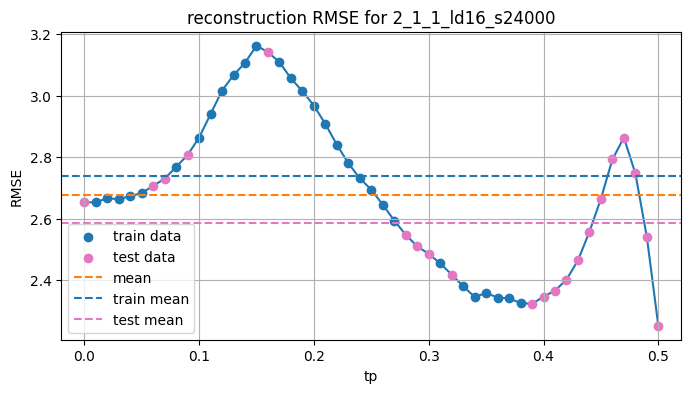

mean: 0.10461880741494109, min: 0.0255393413950728, max: 0.2225823101439754
training data only - mean: 0.1067851910712812, min: 0.0255393413950728, max: 0.2225823101439754
test data only - mean: 0.1015239736201695, min: 0.0259493921294586, max: 0.2170961704475397


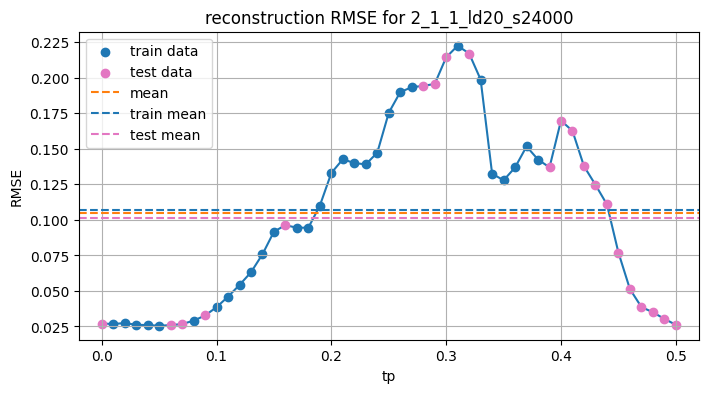

mean: 0.08014797751328752, min: 0.0184071548759922, max: 0.1798538481338467
training data only - mean: 0.08317799366298718, min: 0.0196821727830009, max: 0.1798538481338467
test data only - mean: 0.07581938301371662, min: 0.0184071548759922, max: 0.1763858645963525


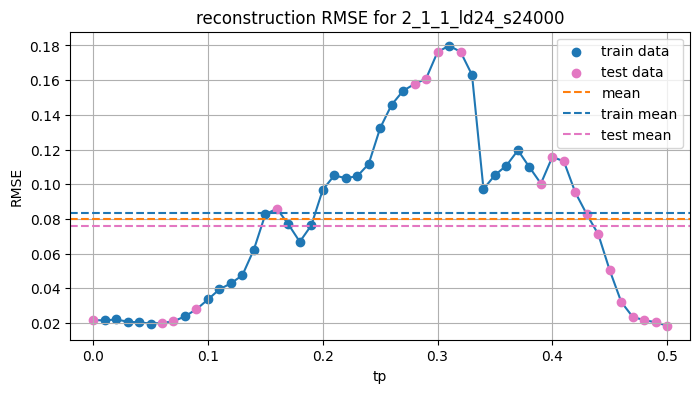

mean: 2.6760353622834434, min: 2.251820037131771, max: 3.1647240129072207
training data only - mean: 2.7387153786140104, min: 2.3281868164792714, max: 3.1647240129072207
test data only - mean: 2.5864924818112063, min: 2.251820037131771, max: 3.1440444292295204


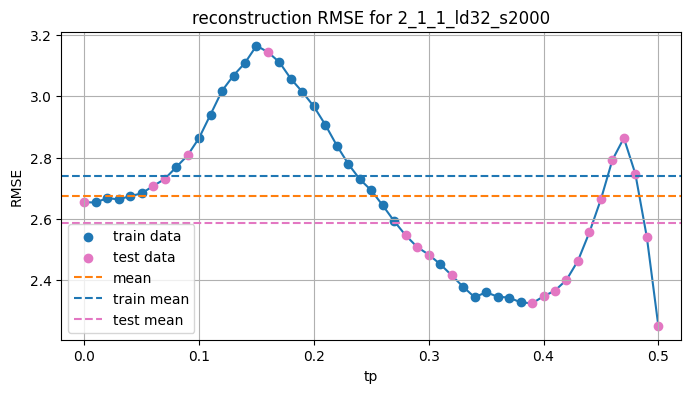

mean: 2.6742561183643114, min: 2.251697232227259, max: 3.160743367671952
training data only - mean: 2.73665305253784, min: 2.3230027348749096, max: 3.160743367671952
test data only - mean: 2.5851176409735577, min: 2.251697232227259, max: 3.139700683723809


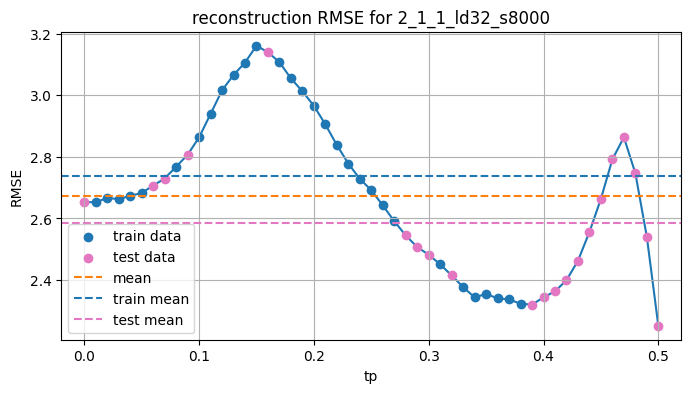

mean: 0.03578493106935763, min: 0.0095067765717626, max: 0.0858708956427293
training data only - mean: 0.03720943055566301, min: 0.0112510071377275, max: 0.0831093258587319
test data only - mean: 0.03374993180320708, min: 0.0095067765717626, max: 0.0858708956427293


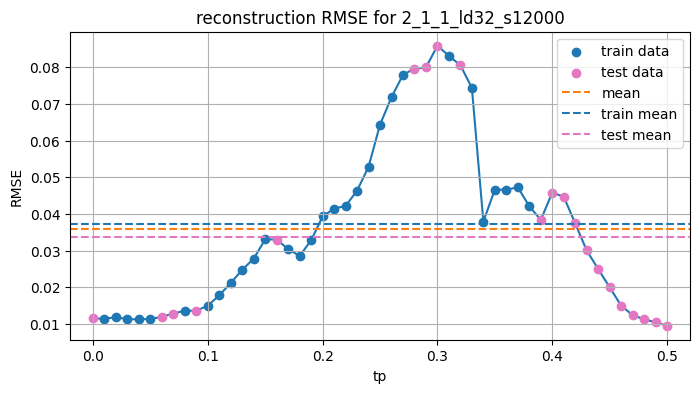

mean: 0.055902942182899026, min: 0.0113518980553117, max: 0.1351146024536373
training data only - mean: 0.05705754293358851, min: 0.0133685394909728, max: 0.1351146024536373
test data only - mean: 0.05425351253905692, min: 0.0113518980553117, max: 0.1322016267766666


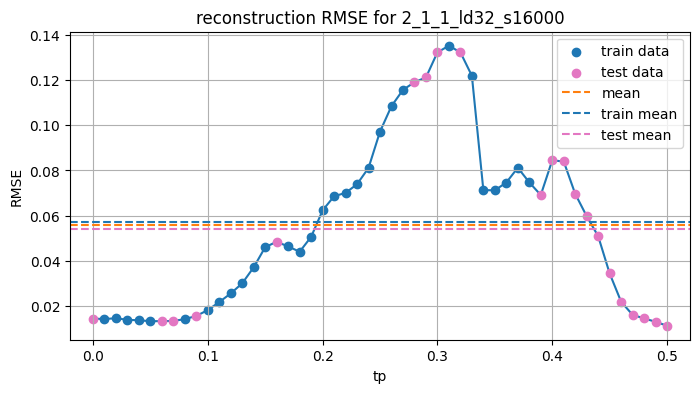

mean: 0.013184983189234209, min: 0.0050832275501072, max: 0.0458725036719538
training data only - mean: 0.013489286917633047, min: 0.0056884251245396, max: 0.0411872357326762
test data only - mean: 0.012750263577235868, min: 0.0050832275501072, max: 0.0458725036719538


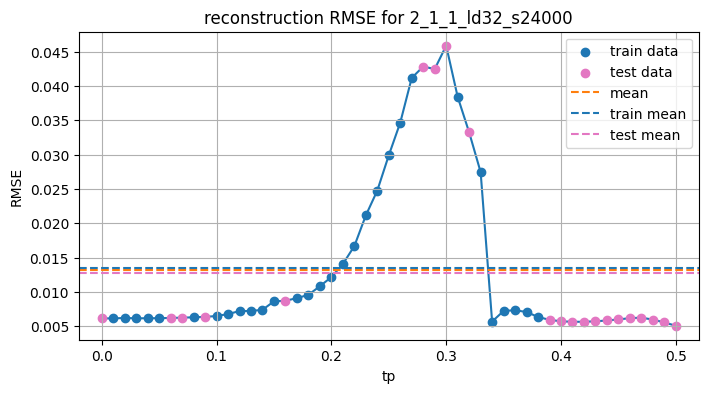

mean: 1.0198410637701556, min: 0.454440241553608, max: 2.829180383653439
training data only - mean: 0.8618186907596392, min: 0.454440241553608, max: 1.369579358536674
test data only - mean: 1.245587310928036, min: 0.5352211618502023, max: 2.829180383653439


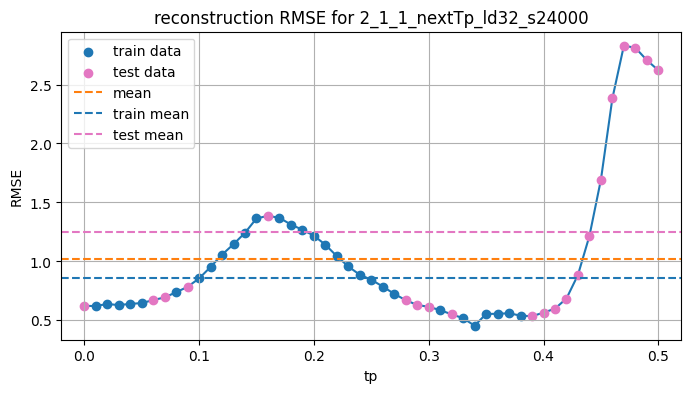

mean: 2.069679472533374, min: 0.1295202216423978, max: 3.167425182621654
training data only - mean: 2.142045142294514, min: 0.1345432401301955, max: 3.167425182621654
test data only - mean: 1.9662999443031743, min: 0.1295202216423978, max: 3.1473711892920506


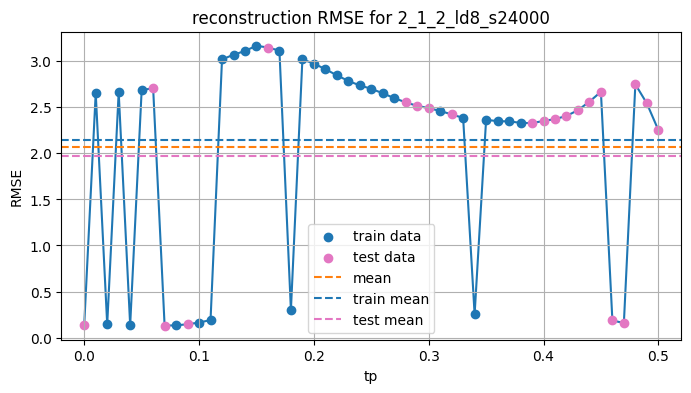

mean: 2.055018030318602, min: 0.0850051109597037, max: 3.163461476970084
training data only - mean: 2.1267831521936373, min: 0.0879800771002928, max: 3.163461476970084
test data only - mean: 1.9524964276399797, min: 0.0850051109597037, max: 3.142880133006756


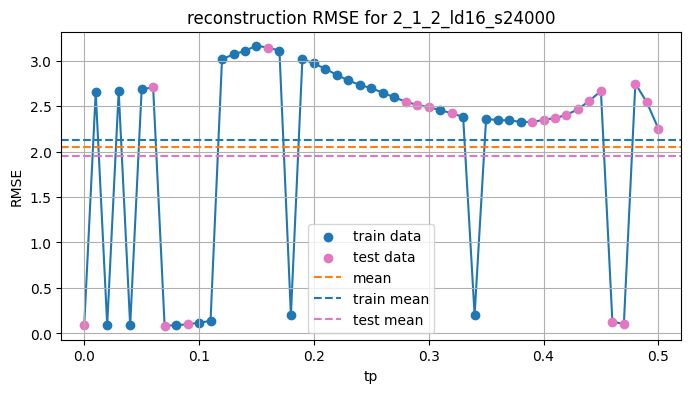

mean: 0.12057980778908887, min: 0.0412985417364552, max: 0.233764591226259
training data only - mean: 0.12316489737174893, min: 0.0412985417364552, max: 0.233764591226259
test data only - mean: 0.11688682267100307, min: 0.0419990193623912, max: 0.226623048098098


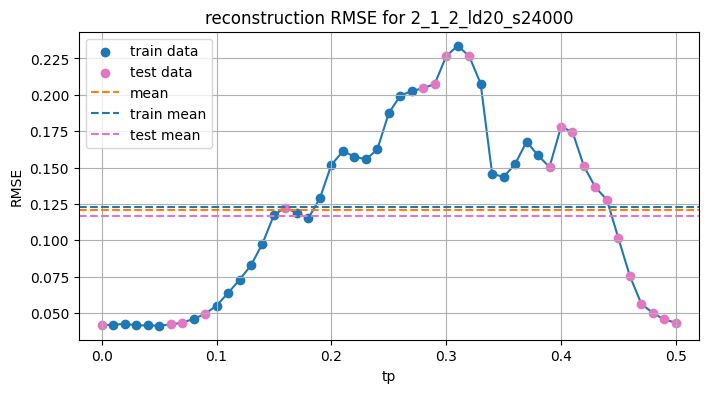

mean: 0.09864261256633138, min: 0.0296839522061908, max: 0.1960727584944648
training data only - mean: 0.10180092697135122, min: 0.0296839522061908, max: 0.1960727584944648
test data only - mean: 0.09413073484487446, min: 0.0305221624855485, max: 0.1908283976774577


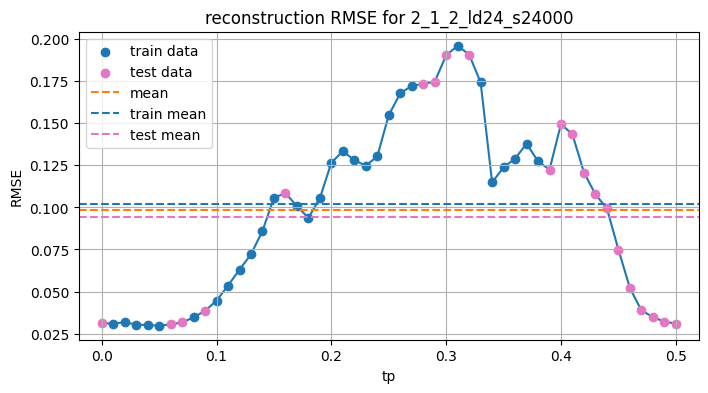

mean: 2.063469544273069, min: 0.1121170414727597, max: 3.1685246969891265
training data only - mean: 2.136378553687864, min: 0.1167939192009629, max: 3.1685246969891265
test data only - mean: 1.9593138165376471, min: 0.1121170414727597, max: 3.1480038646003807


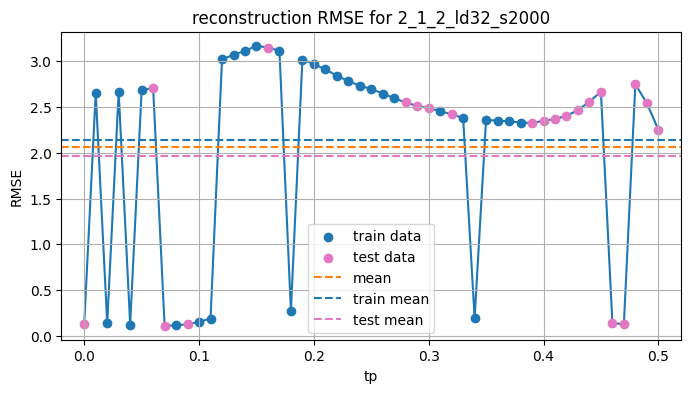

mean: 2.04267429678966, min: 0.05179313569046, max: 3.16187933072302
training data only - mean: 2.11385581440991, min: 0.05179313569046, max: 3.16187933072302
test data only - mean: 1.9409864144750169, min: 0.0527422758745657, max: 3.1408897381580245


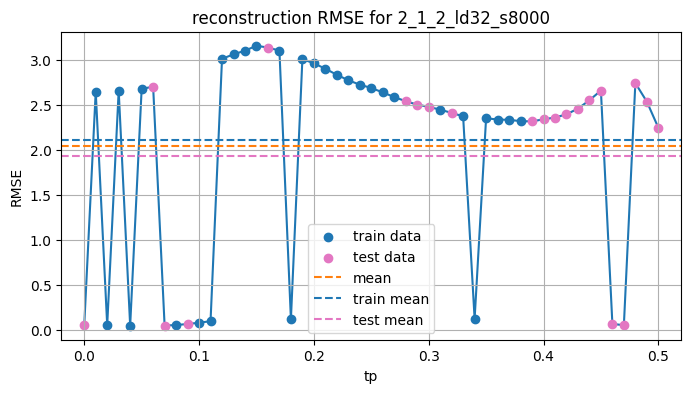

mean: 0.0686202417961813, min: 0.0213086456672753, max: 0.1508856340845076
training data only - mean: 0.07129174540668347, min: 0.0213086456672753, max: 0.1508856340845076
test data only - mean: 0.06480380806689252, min: 0.0215480262083638, max: 0.1492534068388578


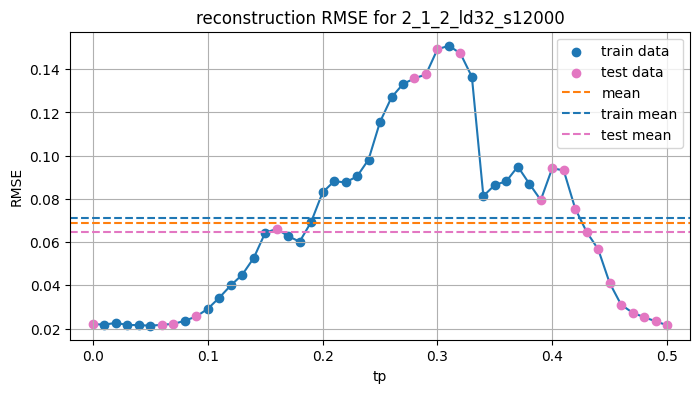

mean: 0.08234654258226756, min: 0.0267415227178833, max: 0.175533211487273
training data only - mean: 0.08536554026296363, min: 0.0267415227178833, max: 0.175533211487273
test data only - mean: 0.07803368875270175, min: 0.0273957824209738, max: 0.1738099830037683


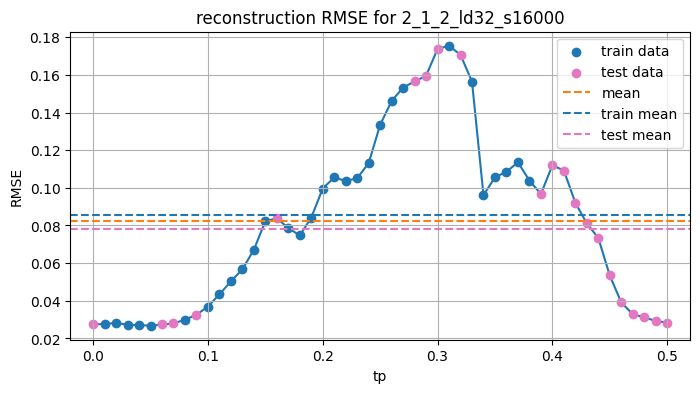

mean: 0.050142020039601116, min: 0.0099877950544564, max: 0.1212516075643841
training data only - mean: 0.05186442489068606, min: 0.0109542978435433, max: 0.1212516075643841
test data only - mean: 0.04768144168090834, min: 0.0099877950544564, max: 0.1201988989948401


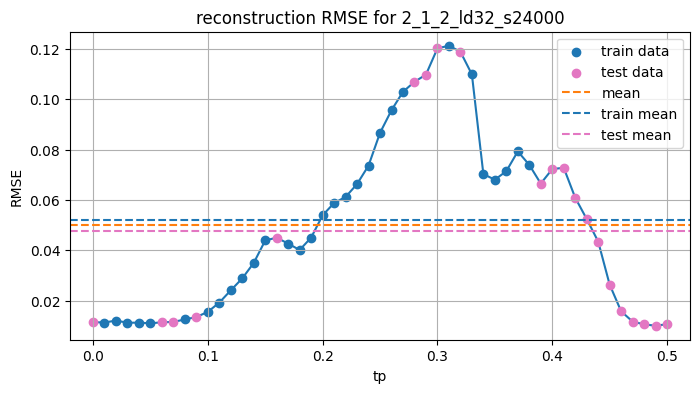

mean: 0.0121603871140918, min: 0.0058375530478607, max: 0.0391191479920111
training data only - mean: 0.010974201504045664, min: 0.0059238150948475, max: 0.0320064394400348
test data only - mean: 0.013300950200674623, min: 0.0058375530478607, max: 0.0391191479920111


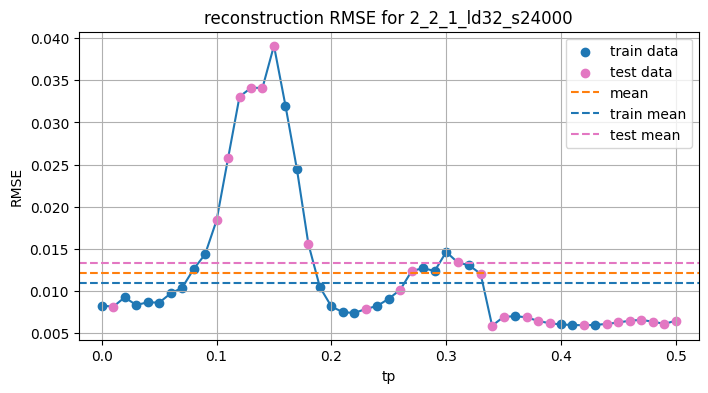

mean: 0.06895452143823697, min: 0.0202025633897922, max: 0.1206453952458018
training data only - mean: 0.06848551661930438, min: 0.0328449415271874, max: 0.1203560571947492
test data only - mean: 0.06940548761028754, min: 0.0202025633897922, max: 0.1206453952458018


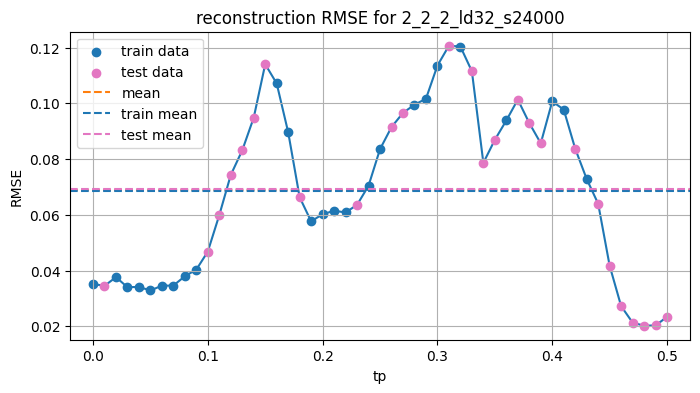

mean: 0.022451293437978, min: 0.0078915471431232, max: 0.0499645579198571
training data only - mean: 0.02398597303871267, min: 0.0079228985645186, max: 0.0499645579198571
test data only - mean: 0.020855226653213942, min: 0.0078915471431232, max: 0.0451950916202639


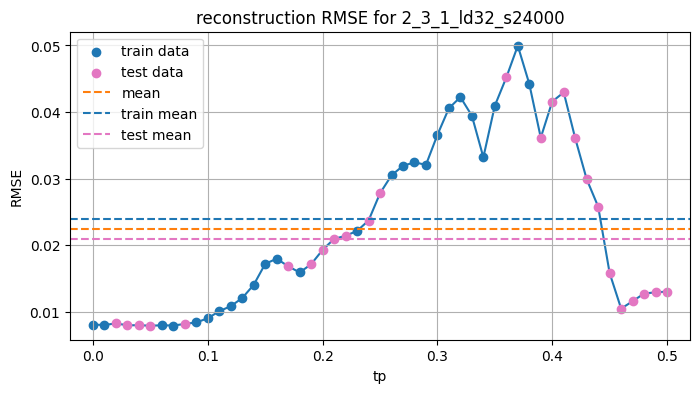

mean: 0.08254003883207443, min: 0.0253999851093343, max: 0.1730044501862688
training data only - mean: 0.09199673086978909, min: 0.025618310979136, max: 0.1730044501862688
test data only - mean: 0.07270507911285119, min: 0.0253999851093343, max: 0.1327989839760628


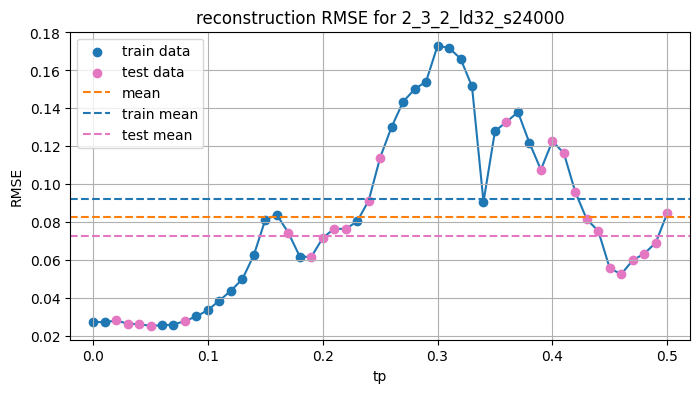

mean: 0.022395867848642417, min: 0.0071936108039418, max: 0.0569210288053406
training data only - mean: 0.022852493386440707, min: 0.0124031144709301, max: 0.0458122857356016
test data only - mean: 0.022284495766252584, min: 0.0071936108039418, max: 0.0569210288053406


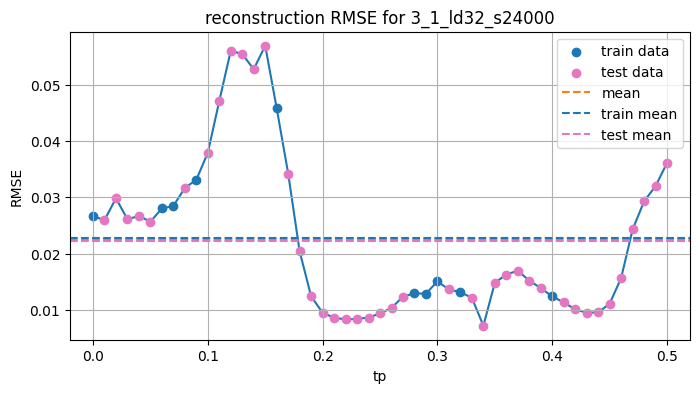

mean: 0.04725331356901858, min: 0.0065086071020485, max: 0.1262982724432749
training data only - mean: 0.05442111429006026, min: 0.0067414256063685, max: 0.1262982724432749
test data only - mean: 0.04397660466797094, min: 0.0065086071020485, max: 0.1257569003418738


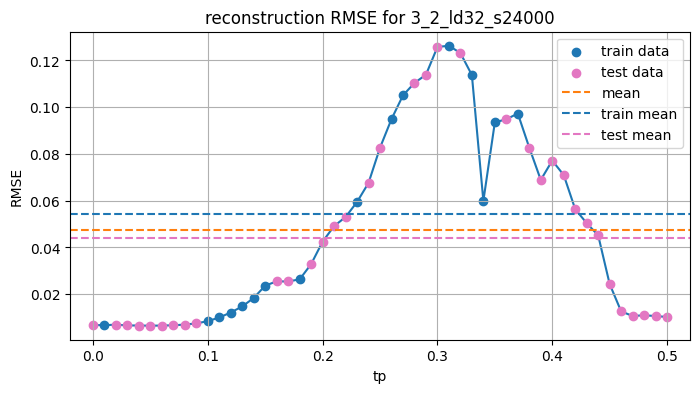

mean: 0.05665236717104675, min: 0.0100097957937402, max: 0.1254708432011849
training data only - mean: 0.05462066549601239, min: 0.0285100450486121, max: 0.0991672201255255
test data only - mean: 0.05742111915619489, min: 0.0100097957937402, max: 0.1254708432011849


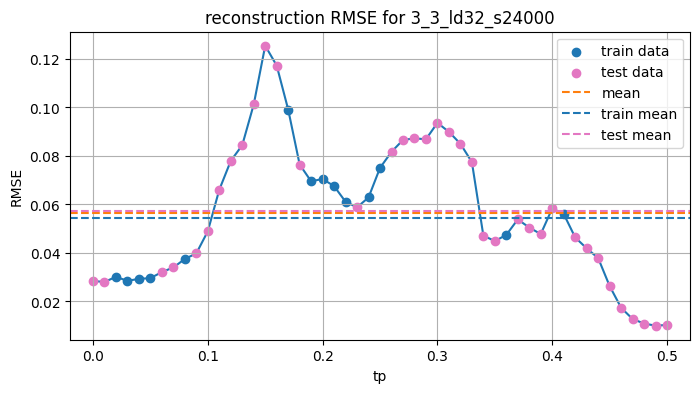

In [2]:
grouped_df = rmse_df.groupby(['run_id', 'ld', 's'])
for (run_id, ld, s), group in grouped_df:
    verteval.print_rmses(group, f'{run_id}_ld{ld}_s{s}')

## convergence

In [9]:
from pathlib import Path

base_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/'
folders = sorted([f.name for f in Path(base_path).iterdir() if f.is_dir()])
labels = {
    '1_1': '1-1 all vertices, simple AE',
    '1_2': '1-2 all vertices, contrastive AE',
    '2_1_1': '2-1-1 exclude SC, simple AE',
    '2_1_2': '2-1-2 exclude SC, contrastive AE',
    '2_2_1': '2-2-1 exclude AFM, simple AE',
    '2_2_2': '2-2-2 exclude AFM, contrastive AE',
    '2_3_1': '2-3-1 exclude FM, simple AE',
    '2_3_2': '2-3-2 exclude FM, contrastive AE',
    '3_1': '3-1 SC only, simple AE',
    '3_2': '3-2 AFM only, simple AE',
    '3_3': '3-3 FM only, simple AE',
}

filtered_folders = folders  # set this to plot only some runs
filtered_labels = []
for f in filtered_folders:
    fsplit = f.split('_')
    pref, suff = '_'.join(fsplit[:-1]), fsplit[-1]
    filtered_labels.append(f"{labels[pref]} ({suff})")
tensorboard_data = vis.get_tensorboard_data(base_path, filtered_folders, filtered_labels)
tensorboard_stats = vis.get_tensorboard_statistics(tensorboard_data)
tensorboard_stats

,wall_time,epoch
run,,
"1-1 all vertices, simple AE (ld32)",35.96,21895
"1-2 all vertices, contrastive AE (ld32)",14.95,24999
"2-1-1 exclude SC, simple AE (ld16)",2.12,2162
"2-1-1 exclude SC, simple AE (ld24)",2.38,2408
"2-1-1 exclude SC, simple AE (ld32)",24.26,24999
"2-1-1 exclude SC, simple AE (ld8)",2.94,2993
"2-1-1 exclude SC, simple AE (s16000)",3.02,4677
"2-1-1 exclude SC, simple AE (s2000)",0.47,4905
"2-1-1 exclude SC, simple AE (s8000)",1.33,3974


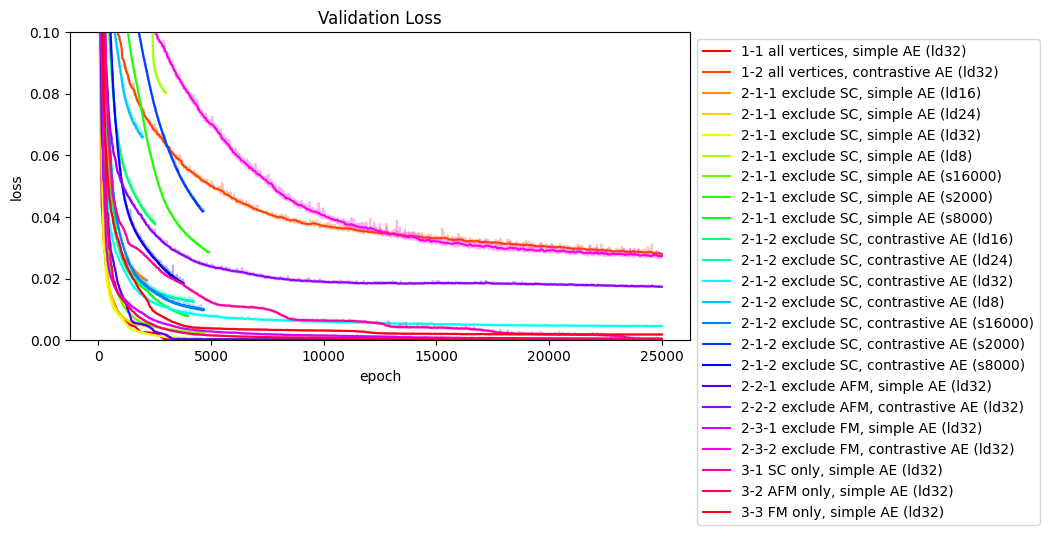

In [10]:
vis.plot_loss_progress(tensorboard_data.dropna(), labels, y_max=0.1, log=False)

## compare phase classifier models

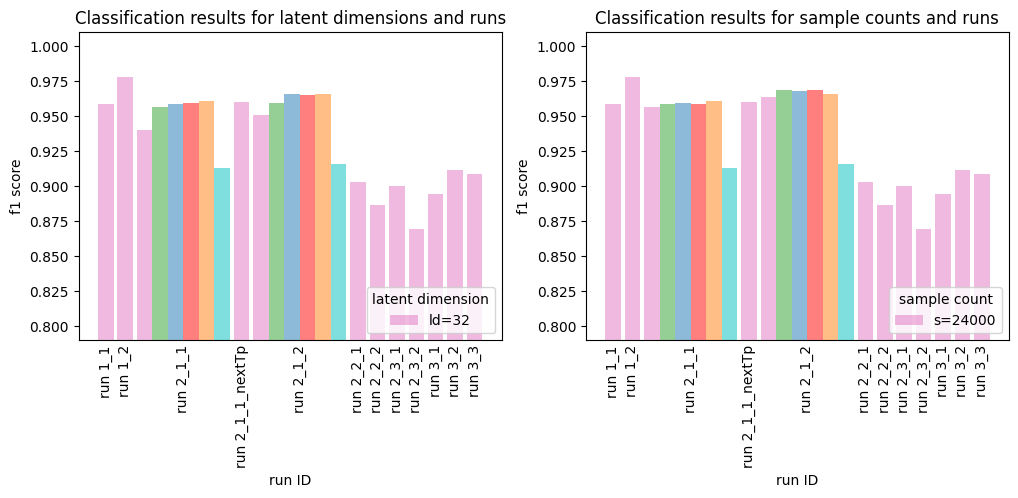

f1
run_id       ld  s              
0            NaN NaN    0.984125
1_1          32  24000  0.958754
1_2          32  24000  0.977773
2_1_1        8   24000  0.940110
             16  24000  0.957021
             20  24000  0.958681
             24  24000  0.959446
             32  2000   0.956765
                 8000   0.958727
                 12000  0.959546
                 16000  0.959113
                 24000  0.960729
                 24000  0.912958
2_1_1_nextTp 32  24000  0.960558
2_1_2        8   24000  0.951040
             16  24000  0.959179
             20  24000  0.966148
             24  24000  0.965585
             32  2000   0.963471
                 8000   0.968983
                 12000  0.967969
                 16000  0.968869
                 24000  0.966148
                 24000  0.915708
2_2_1        32  24000  0.903177
2_2_2        32  24000  0.886500
2_3_1        32  24000  0.900448
2_3_2        32  24000  0.869760
3_1          32  24000  0.894312
3_2          32  24000  0.911354
3_3          32  24000  0.909073

In [11]:
verteval.plot_classification_results(classification_df, figsize=(12, 4))

2_1_1_ld32_s24000


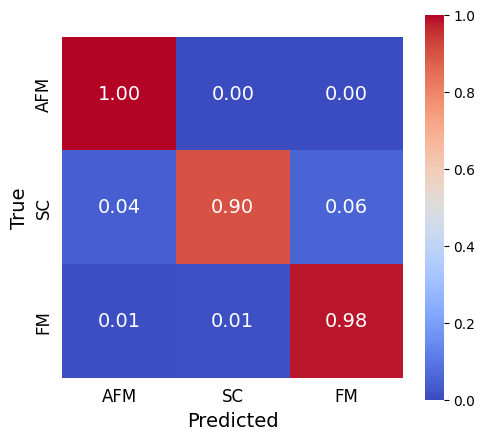

2_1_1_nextTp_ld32_s24000


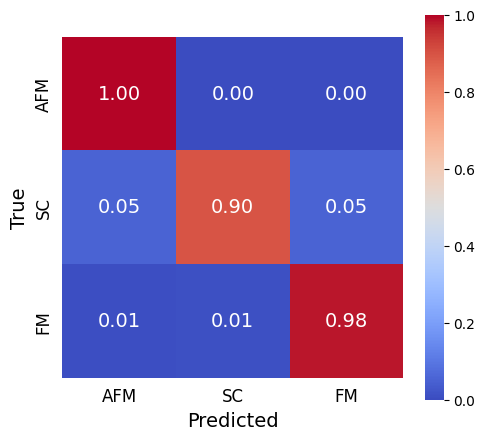

In [15]:
labels = [label.upper() for label in list(AutoEncoderVertexDataset.phase_borders.keys())]

row = classification_df[(classification_df['run_id'] == '2_1_1') & (classification_df['ld'] == 32) & (classification_df['s'] == 24000)].iloc[0]
vertvis.print_conf_mat(row['conf_mat'], f"{row['run_id']}_ld{row['ld']}_s{row['s']}", labels)

row = classification_df[classification_df['run_id'] == '2_1_1_nextTp'].iloc[0]
vertvis.print_conf_mat(row['conf_mat'], f"{row['run_id']}_ld{row['ld']}_s{row['s']}", labels)

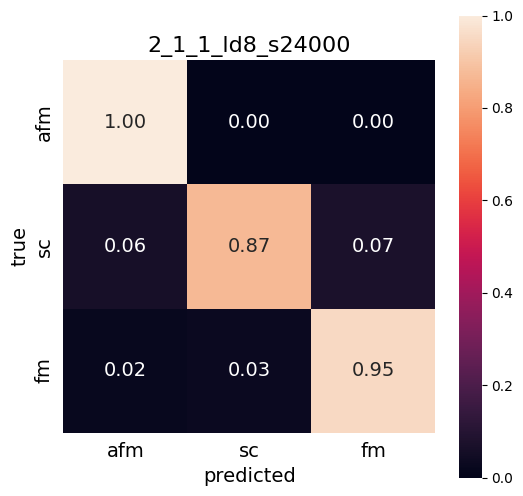

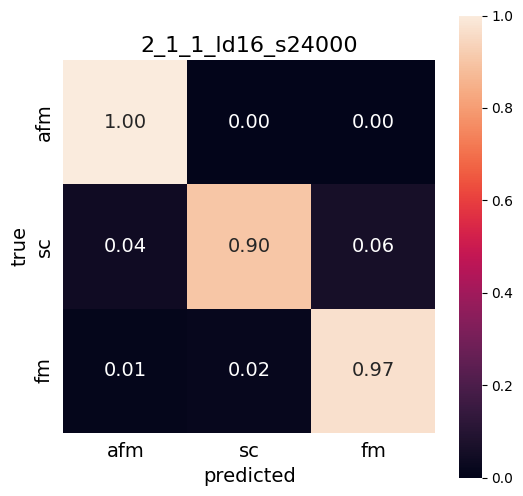

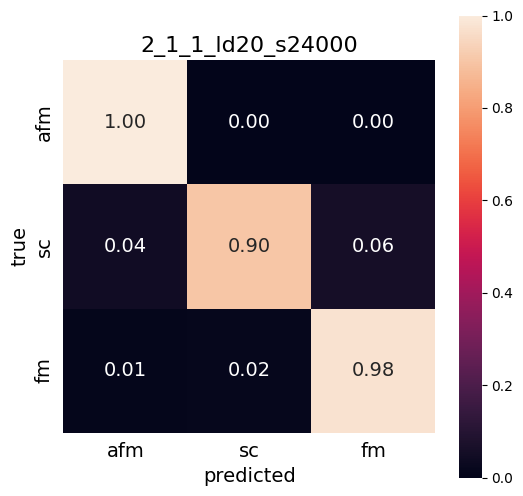

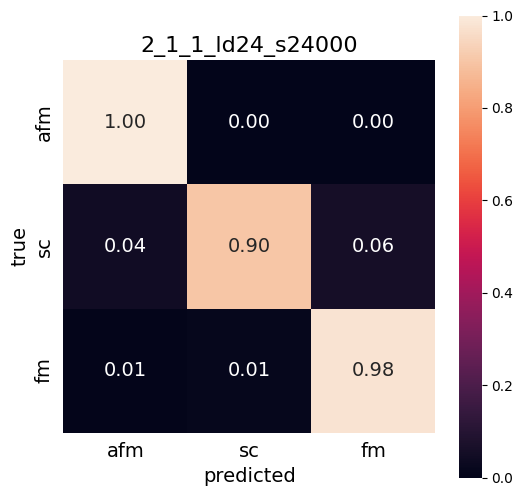

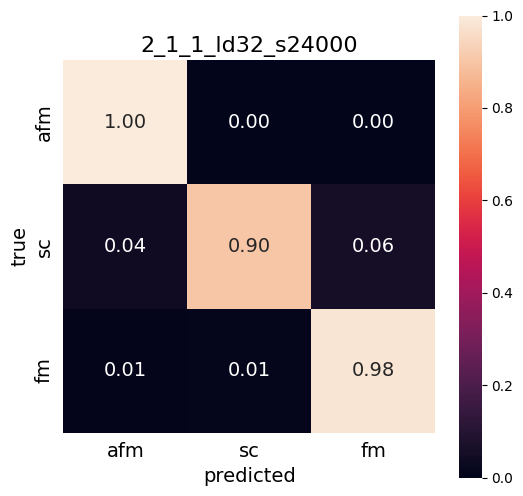

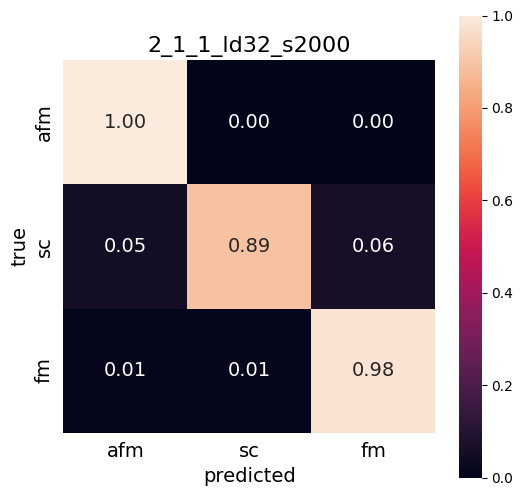

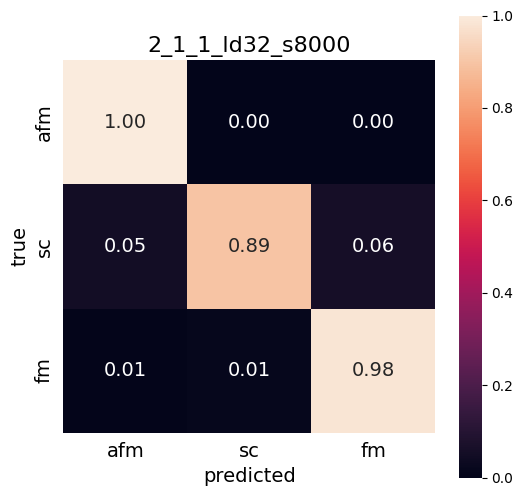

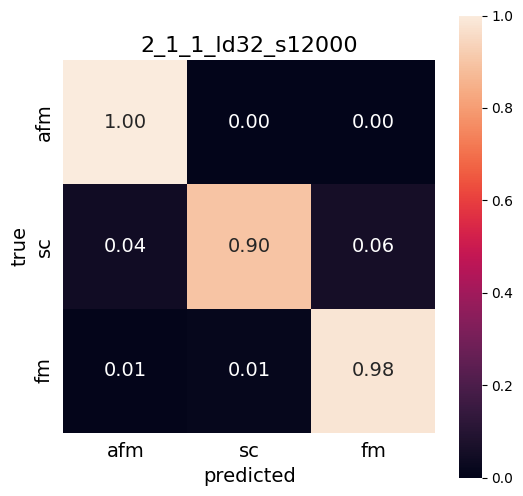

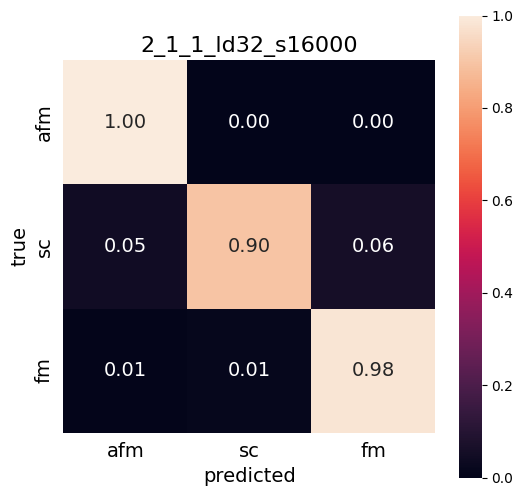

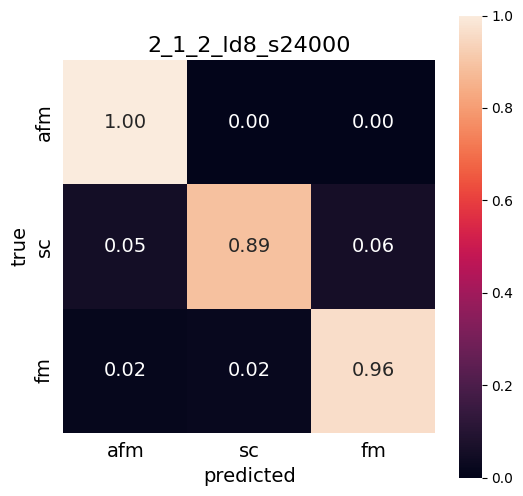

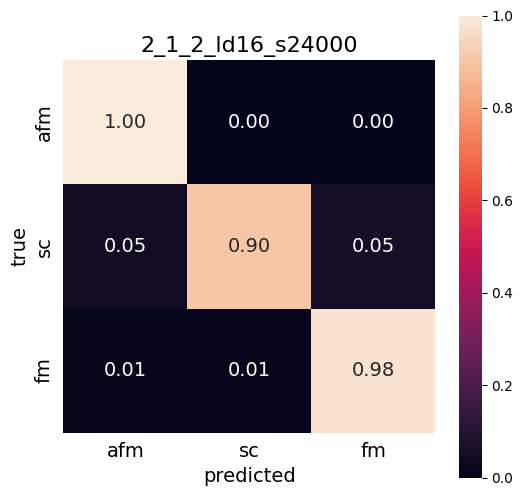

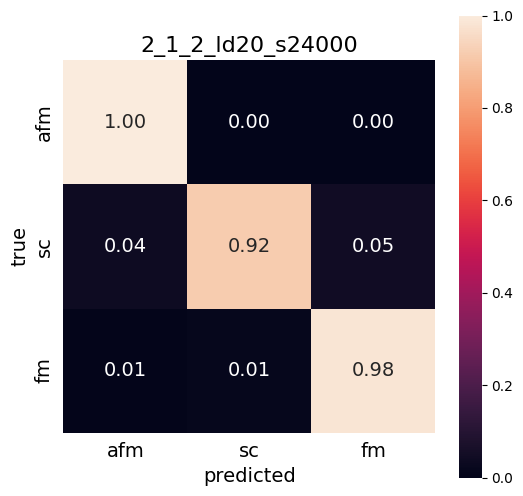

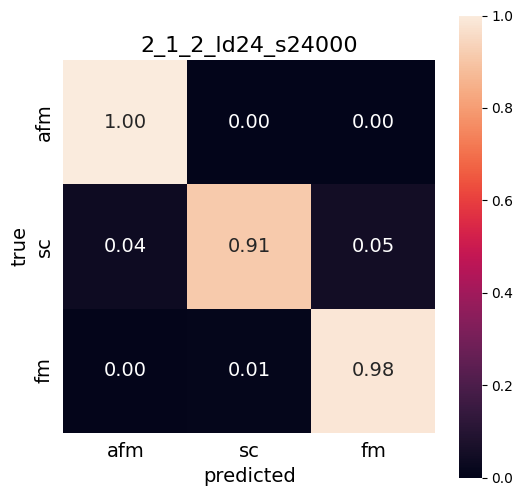

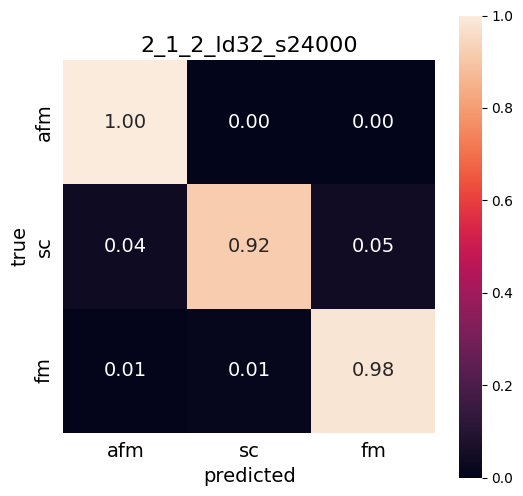

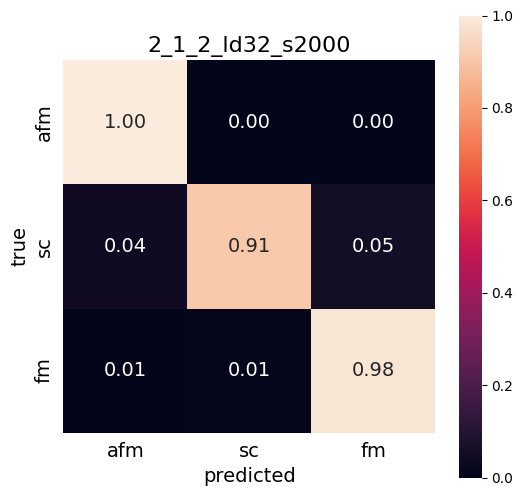

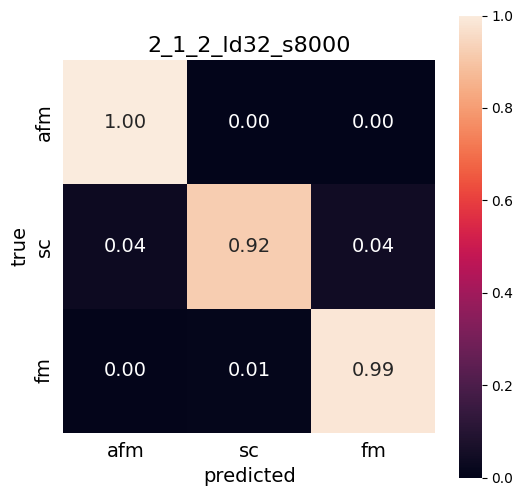

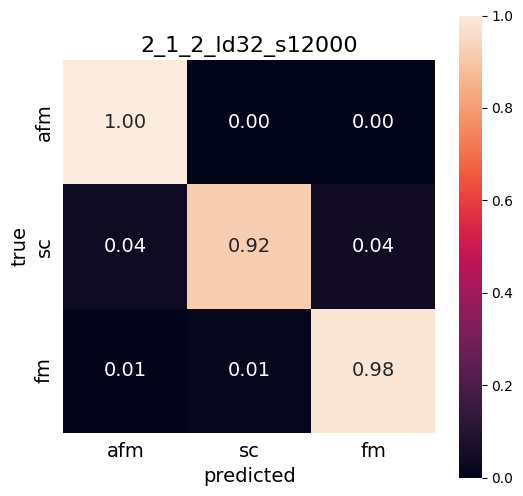

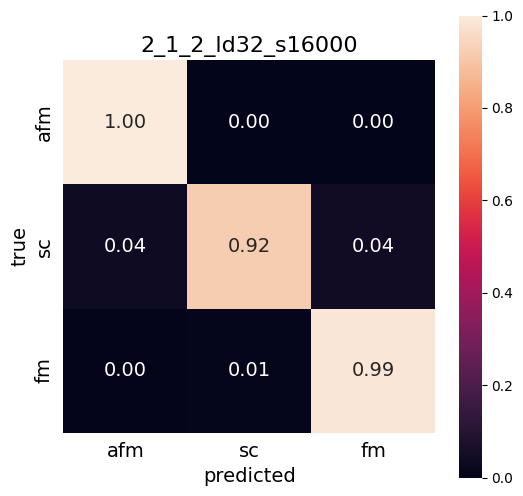

In [14]:
labels = [label.upper() for label in list(AutoEncoderVertexDataset.phase_borders.keys())]
for i, row in classification_df.iterrows():
    verteval.print_conf_mat(row['conf_mat'], f"{row['run_id']}_ld{row['ld']}_s{row['s']}", labels)

## compare vertex reconstructions

In [2]:
base_path = Path('/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/')
vertex_path_dict = {float(fp.stem[2:6]): fp for fp in data_dir.glob('*.h5')}

In [8]:
# set the run and tp-parameter for which you want to comparte original and reconstruction
runs_to_plot = ['2_1_1_ld8', '2_1_1_ld32']
tp_to_plot = [0.22, 0.33]

vertices = [AutoEncoderVertex24x6Dataset.load_from_file(vertex_path_dict[tp]) for tp in tp_to_plot]
predictions = {run_id: [np.load(base_path / run_id / 'predictions' / (vertex_path_dict[tp].stem + '.npy')) for tp in tp_to_plot] 
               for run_id in runs_to_plot}

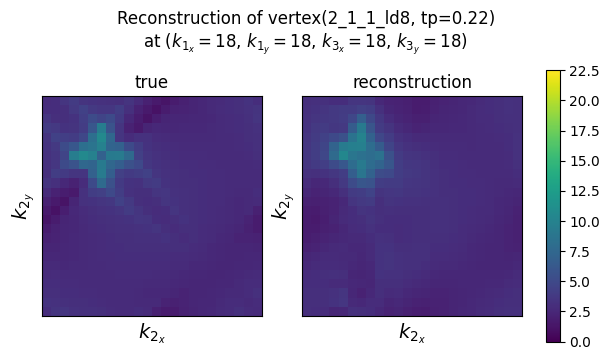

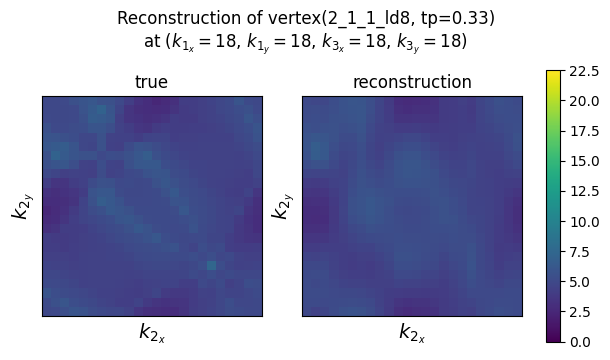

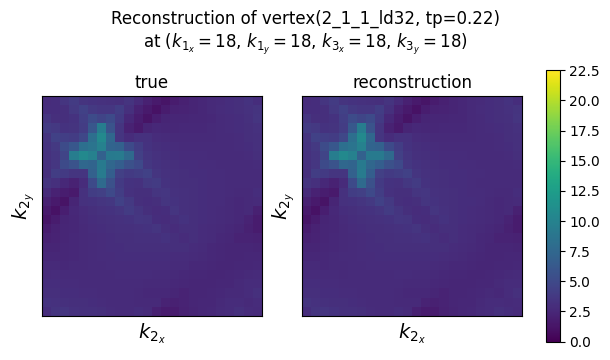

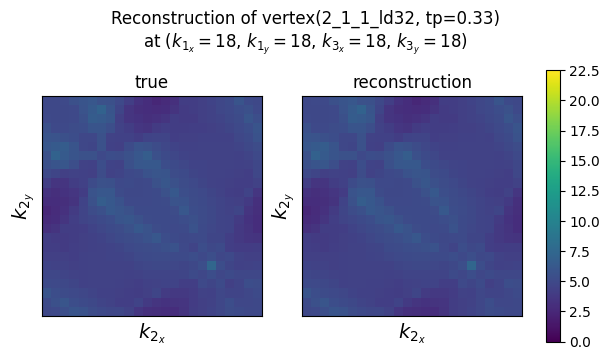

In [9]:
i = 18
axis = 3
nrows, ncols = 1, 2
slice_at = (i, i, i, i)
other_ks = set(range(1,4)) - {(axis + 1) // 2}
params_str = ', '.join([f'$k_{{{k}_{c}}}={sl}$' for (k, c), sl 
                        in zip([(k, c) for k in other_ks for c in ['x', 'y']], slice_at)])

for run_id, preds in predictions.items():
    for tp, true, pred in zip(tp_to_plot, vertices, preds):
        fn = vertex_path_dict[tp].stem
        true_slice = vertvis.get_mat_slice(true, axis, slice_at)
        pred_slice = vertvis.get_mat_slice(pred, axis, slice_at)
        plot_data = {'true': true_slice, 'reconstruction': pred_slice}
        vertvis.plot_compare_grid(plot_data, nrows, ncols, axis, None, figsize=(6, 4), 
                                  title=f'Reconstruction of vertex({run_id}, tp={tp})\nat ({params_str})', vmin=0.0, vmax=22.5)